In [162]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [163]:
#Retrieve data

ticker = "TSLA"
end = dt.datetime.now()
start = end - dt.timedelta(days = 365 * 2)

df = yf.download(ticker, start = start, end = end, auto_adjust = False)
df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [164]:
#Calculate the True Range and moving true range

df['H-L'] = df['High'] - df['Low'] #High - Low
df['H-PC'] = abs(df['High'] - df['Close'].shift(1)) #High - previous close
df['L-PC'] = abs(df['Low'] - df['Close'].shift(1)) #Low - previous close

atr_period = 14

df['True Range'] = df[['H-L', 'H-PC', 'L-PC']].max(axis = 1) #True Range
df['Avg True Range'] = df['True Range'].rolling(window = atr_period).mean()

In [165]:
df = df.drop(['H-L', 'H-PC', 'L-PC', 'True Range'], axis = 1)

multiplier = 2

df['Upper band'] = df['Close'] + (df['Avg True Range'] * multiplier)
df['Upper band'] = df['Upper band'].shift(1)
df['Lower band'] = df['Close'] - (df['Avg True Range'] * multiplier)
df['Lower band'] = df['Lower band'].shift(1)

In [166]:
def give_signal(row):
    if pd.isna(row['Avg True Range']):
        return np.nan
    elif row['Close'] > row['Upper band']:
        return 1
    elif row['Close'] < row['Lower band']:
        return -1
    else:
        return np.nan

df['signal'] = df.apply(give_signal, axis=1)

df['signal'] = df['signal'].ffill()

Benchmark return: 103.30%
Strategy return: 108.27%


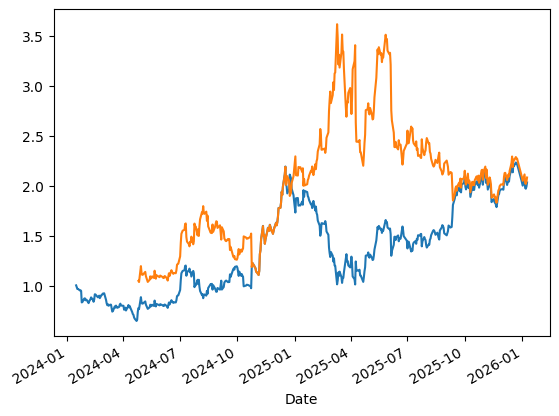

In [167]:
returns = df['Adj Close'].pct_change()
strat = df['signal'].shift(1) * returns

benchReturns = (1 + returns).cumprod()
benchReturns.plot()

stratReturns = (1 + strat).cumprod()
stratReturns.plot()

print(f'Benchmark return: {(benchReturns.iloc[-1] - 1) * 100:0.2f}%')
print(f'Strategy return: {(stratReturns.iloc[-1] - 1) * 100:0.2f}%')